# Quick Data Exploration — Linz Open Data

This notebook does a first-pass EDA over every dataset in this folder so we can decide
**which topic to build the hackathon project around**. The data is all open data
from the City of Linz, Austria, covering:

| # | File | Topic | Rows |
|---|------|-------|------|
| 1 | `Defibrillatoren.csv` | Public defibrillator (AED) locations | 283 |
| 2 | `HUNDEZONEN.json` | Dog zones (leash-free areas / no-dog zones), GeoJSON polygons | 140 |
| 3 | `Hecken-die-schmecken.csv` | "Edible hedges" — public berry hedges | 21 |
| 4 | `Herkunftslaender.csv` | Tourism: visitor arrivals & overnight stays by country of origin | 233 |
| 5 | `Linztermine.json` | City events calendar (events, locations, organizers, tags) | 211 events |
| 6 | `Strassennamen-aktuell.csv` | Street names & the people they're named after | 1212 |
| 7 | `Trinkbrunnen.csv` | Public drinking fountains | 133 |
| 8 | `WC-Anlagen.csv` | Public toilets | 69 |
| 9 | `spielplaetze_und_sportanlagen.csv` | Playgrounds & sports facilities | 159 |

For each dataset we look at: shape & schema, missing data, key category breakdowns,
and (where coordinates exist) a spatial scatter. We close with a cross-dataset
map and a shortlist of candidate hackathon topics grounded in what the data
actually supports.


In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

def overview(df, name):
    """Print a compact profile of a dataframe."""
    print(f"=== {name} ===")
    print("shape:", df.shape)
    print()
    print(df.dtypes)
    print()
    missing = df.isna().mean().sort_values(ascending=False)
    missing = missing[missing > 0]
    if len(missing):
        print("columns with missing values (share):")
        print(missing.round(3))
    else:
        print("no missing values")


## 1. Defibrillatoren — public AED locations

In [2]:
defi = pd.read_csv("Defibrillatoren.csv")
overview(defi, "Defibrillatoren")
defi.head()

=== Defibrillatoren ===
shape: (282, 12)

id                       str
FIRMA                    str
Adresse                  str
PLZ                  float64
Stadt                    str
Marke/Hersteller         str
Standort                 str
quell_lat            float64
quell_lon            float64
lat                  float64
lon                  float64
koordinatenstatus        str
dtype: object

columns with missing values (share):
Standort     0.057
lat          0.021
lon          0.021
quell_lat    0.018
quell_lon    0.018
Adresse      0.011
PLZ          0.011
Stadt        0.011
dtype: float64


,id,FIRMA,Adresse,PLZ,Stadt,Marke/Hersteller,Standort,quell_lat,quell_lon,lat,lon,koordinatenstatus
0,defi_a84933cd1a5d5bae9a93,Adalbert Stifter Institut,Adalbert-Stifter-Platz 1,4020.0,Linz,Lifepak CR+,2. Stock Sekretariat,48.307533,14.288317,48.307533,14.288317,plausibel
1,defi_a779079088b30fb74708,"Amt der Oberösterreichischen Landesregierung, ...",Altstadt 30,4020.0,Linz,Heartstart FRx,"Amtsgebäude Altstadt 30, 2. OG Stiegenhaus",48.304426,14.284791,48.304426,14.284791,plausibel
2,defi_2a42a40632768ea2e8f1,Dynatrace Austria GmbH,Am Fünfundzwanziger Turm 20,4020.0,Linz,Lifepak CR2 WLAN,Erdgeschoß - Empfangsbereich,48.315184,14.305345,48.315184,14.305345,plausibel
3,defi_b120deafa56319554ef5,Linz AG,Am Pöstlingberg 16,4020.0,Linz,Lifepak CR+,"Grottenbahn - Shop, bei EH-Kasten",48.323500,14.257316,48.323500,14.257316,plausibel
4,defi_e9cee4d4cecaa37f4ad2,OÖ Theater und Orchester GmbH - Musiktheater Linz,Am Volksgarten 1,4020.0,Linz,Lifepak CR+,Kassa,48.294645,14.293015,48.294645,14.293015,plausibel


In [3]:
print("unique brands/models:", defi["Marke/Hersteller"].nunique())
defi["Marke/Hersteller"].value_counts().head(10)

unique brands/models: 9


Marke/Hersteller
Lifepak CR+         157
Heartstart FRx       46
Fred Easy            25
Lifepak Express      21
Lifepak CR2 WLAN     19
Heartstart HS1        9
Fred Easy Life        2
Lifepak CR2 USB       2
Zoll AED Plus         1
Name: count, dtype: int64

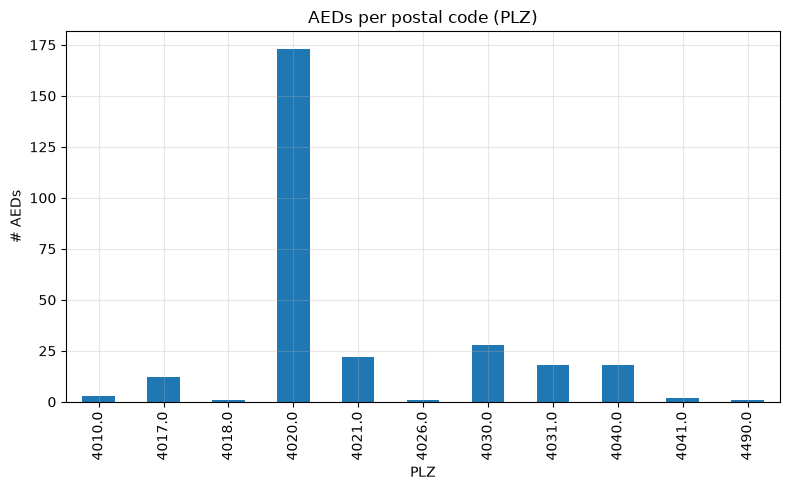

In [4]:
defi["PLZ"].value_counts().sort_index().plot(kind="bar", title="AEDs per postal code (PLZ)")
plt.xlabel("PLZ")
plt.ylabel("# AEDs")
plt.tight_layout()
plt.show()

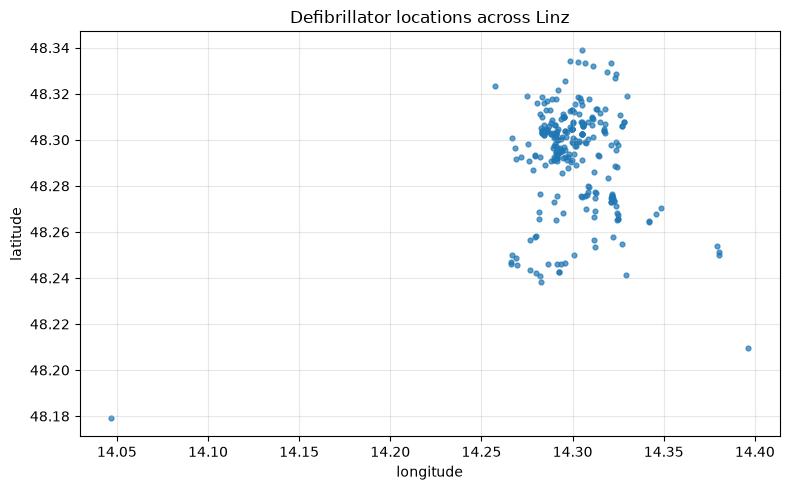

In [5]:
fig, ax = plt.subplots()
ax.scatter(defi["lon"], defi["lat"], s=12, alpha=0.7)
ax.set_title("Defibrillator locations across Linz")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
plt.tight_layout()
plt.show()

## 2. HUNDEZONEN — dog zones (GeoJSON)

Polygons for two kinds of areas: `Verbotszone` (dogs must be leashed / banned) and
`Freilauffläche` (off-leash area).

In [6]:
with open("HUNDEZONEN.json", encoding="utf-8") as f:
    hz_raw = json.load(f)

print("feature count:", len(hz_raw["features"]))

def polygon_centroid(coords):
    ring = coords[0]
    lons = [p[0] for p in ring]
    lats = [p[1] for p in ring]
    return float(np.mean(lons)), float(np.mean(lats))

rows = []
for feat in hz_raw["features"]:
    props = feat["properties"]
    lon, lat = polygon_centroid(feat["geometry"]["coordinates"])
    rows.append({**props, "centroid_lon": lon, "centroid_lat": lat})

hundezonen = pd.DataFrame(rows)
overview(hundezonen, "HUNDEZONEN")
hundezonen.head()

feature count: 140
=== HUNDEZONEN ===
shape: (140, 10)

GDOID               str
FLAECHE         float64
NAME                str
FLART               str
ZUSATZ              str
ZAUN                str
ZUST                str
ANMERKUNG           str
centroid_lon    float64
centroid_lat    float64
dtype: object

no missing values


,GDOID,FLAECHE,NAME,FLART,ZUSATZ,ZAUN,ZUST,ANMERKUNG,centroid_lon,centroid_lat
0,0324cde1-e79e-4cfd-b96f-737efb18eee1,1711.74,Darrgutstraße,Verbotszone,,,SGS,,14.308765,48.301687
1,05cba79b-acdd-4e58-8507-fa6ccbf4bdfe,102.45,Aboretum-Maximilianweg,Verbotszone,,,SGS,,14.268269,48.296504
2,06b18452-c79e-4f20-b1a6-4901fabfb950,1129.87,Am Alten Feldweg,Verbotszone,,,SGS,,14.281896,48.333040
3,090643bd-a79f-4292-9d43-0189f3a38ce2,11036.50,Ing. Sternstraße,Verbotszone,,,SGS,,31.307958,31.308046
4,0b671ea6-0efd-4087-afbc-2d08d6664f9f,692.06,Steinmetzplatzl,Verbotszone,,,SGS,,14.279952,48.308708


In [7]:
print(hundezonen["FLART"].value_counts())
print()
print("total area (m^2) by zone type:")
print(hundezonen.groupby("FLART")["FLAECHE"].sum().round(0))

FLART
Verbotszone       127
Freilauffläche     13
Name: count, dtype: int64

total area (m^2) by zone type:
FLART
Freilauffläche    678893.0
Verbotszone       504039.0
Name: FLAECHE, dtype: float64


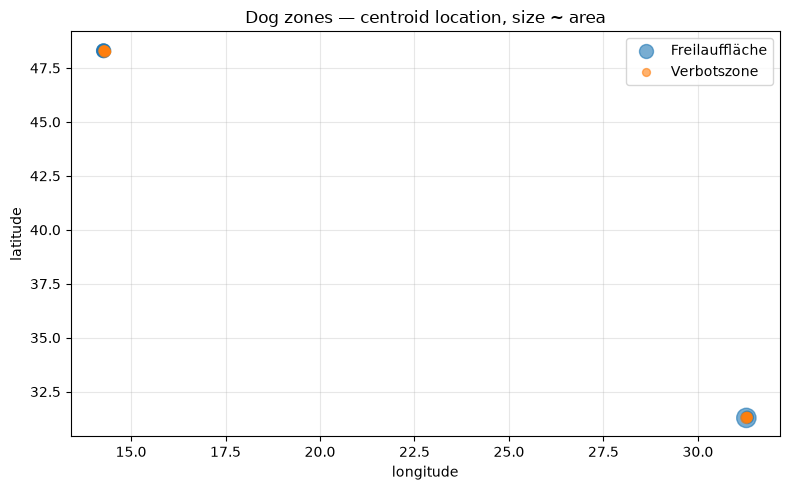

In [8]:
fig, ax = plt.subplots()
for flart, sub in hundezonen.groupby("FLART"):
    ax.scatter(sub["centroid_lon"], sub["centroid_lat"], s=sub["FLAECHE"] ** 0.5 / 3,
               alpha=0.6, label=flart)
ax.set_title("Dog zones — centroid location, size ~ area")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Hecken-die-schmecken — edible public hedges

A small, quirky dataset (21 rows) of public berry hedges. Too small for standalone
statistical analysis, but worth a quick text look — what kinds of berries/plants
show up, and where.

In [9]:
hecken = pd.read_csv("Hecken-die-schmecken.csv")
overview(hecken, "Hecken-die-schmecken")
hecken

=== Hecken-die-schmecken ===
shape: (20, 4)

id              str
standort        str
beschreibung    str
art             str
dtype: object

no missing values


,id,standort,beschreibung,art
0,hecke_fa3d813f3c5aaf31b5b8,Baumgärtlstraße,"Park, ca. 5lfm, bogenförmig, entlang des Weges...","gemischt, Ribisel"
1,hecke_2a3bea247daf105e5b93,Johann-Wilhelm-Klein-Anlage,entlang des Weges gemischte Beeren,gemischt
2,hecke_6cdf3e405892224b5a6c,Pulvermühlpark,"Pulvermühlpark, ca. 5 lfm. entlang des Weges g...",gemischt
3,hecke_2e2daff032cd2a0f8c37,Biesenfeldanlage,"Biesenfeldanlage, zwischen Bäuemen gemischte B...",gemischt
4,hecke_552b312e3607f5080dc1,Grünmarkt,ca. 5 lfm. Anschließend an einen Streifen gemi...,"Ribisel, Himbeere"
5,hecke_a25463da0376e79c3c5e,Ottensheimer Straße,"3 rote Ribisel, 2 weiße Ribisel, 1 Dirndl, 4 J...","Ribisel, Dirndl, Japanische Weinbeeren, Josta,..."
6,hecke_444d4a4d7bf342af0800,BH-Uhrfahr,Himbeeren rundlich vor Beet,Himbeere
7,hecke_044fd859f17347865f2e,Harbachpark,5lfm Ribisel,Ribisel
8,hecke_019ccedbcdde00a30cc2,Unipark,"hinter Juridikum, vor Wolfauerstraße: 5 rote R...","Ribisel, Himbeere, Josta"
9,hecke_e19f1e2335c6dfd7ef6e,Arboretum/Freinberg,Nähe Holzheimerstraße,"Ribisel, Stachelbeere, Brombeere"


In [10]:
# crude keyword count across the "art" (species) column
from collections import Counter
species = Counter()
for entry in hecken["art"].dropna():
    for token in entry.split(","):
        species[token.strip()] += 1
pd.Series(species).sort_values(ascending=False)

Ribisel                  13
Himbeere                  8
Josta                     8
Brombeere                 5
gemischt                  4
Stachelbeere              4
Japanische Weinbeeren     2
Dirndl                    1
Stachelbeer               1
Amelanchier               1
Himbeeren                 1
Himbeere; Ribisel         1
japanische Weinbeere      1
dtype: int64

## 4. Herkunftslaender — tourism arrivals & overnight stays (2024, by quarter)

In [11]:
herkunft = pd.read_csv("Herkunftslaender.csv")
overview(herkunft, "Herkunftslaender")
herkunft.head()

=== Herkunftslaender ===
shape: (232, 8)

id                   str
jahr               int64
quartal            int64
herkunft             str
herkunft_typ         str
iso2                 str
ankuenfte          int64
uebernachtungen    int64
dtype: object

columns with missing values (share):
iso2    0.224
dtype: float64


,id,jahr,quartal,herkunft,herkunft_typ,iso2,ankuenfte,uebernachtungen
0,herkunft_80e0baa7c48d2a1535ab,2024,1,Österreich,land,AT,60369,106042
1,herkunft_75d61b8a26af7142ff5f,2024,2,Österreich,land,AT,85972,145231
2,herkunft_7aa062c2b74008afbe0d,2024,3,Österreich,land,AT,65854,120977
3,herkunft_3595f55d6d3d12921430,2024,4,Österreich,land,AT,76506,131387
4,herkunft_13ea7a774a51af771d47,2024,1,darunter Wien,gruppe,NaN,14741,24447


In [12]:
print(herkunft["herkunft_typ"].value_counts())
print("years covered:", sorted(herkunft["jahr"].unique()))
print("quarters covered:", sorted(herkunft["quartal"].unique()))

herkunft_typ
land      180
gruppe     48
summe       4
Name: count, dtype: int64
years covered: [np.int64(2024)]
quarters covered: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


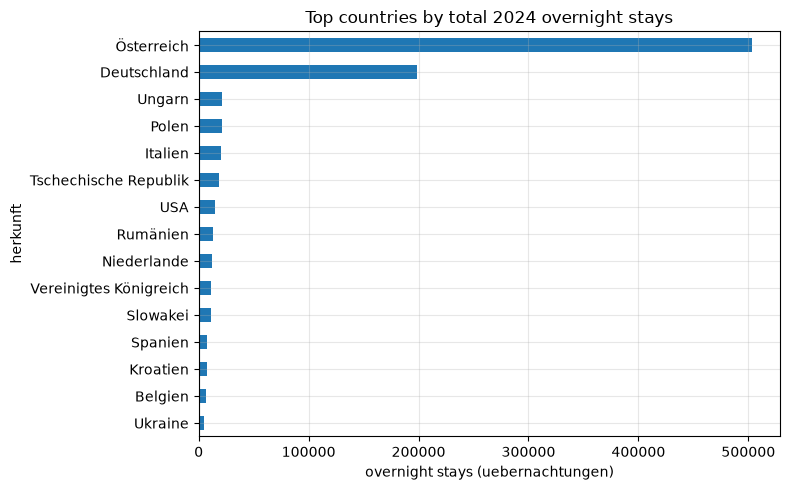

In [13]:
countries = herkunft[herkunft["herkunft_typ"] == "land"]
top_countries = (countries.groupby("herkunft")["uebernachtungen"].sum()
                  .sort_values(ascending=False).head(15))
top_countries.plot(kind="barh", title="Top countries by total 2024 overnight stays")
plt.xlabel("overnight stays (uebernachtungen)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

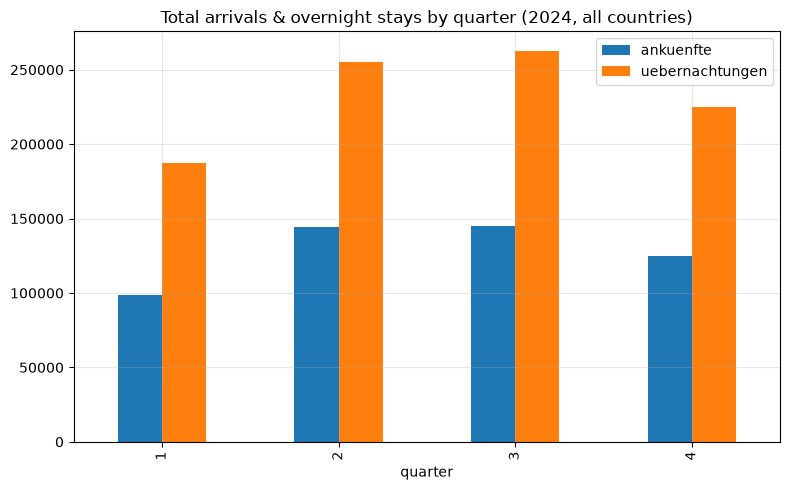

In [14]:
quarterly = countries.groupby("quartal")[["ankuenfte", "uebernachtungen"]].sum()
quarterly.plot(kind="bar", title="Total arrivals & overnight stays by quarter (2024, all countries)")
plt.xlabel("quarter")
plt.tight_layout()
plt.show()

## 5. Linztermine — city events calendar

Nested dataset: `events`, `locations`, `organizers`, `tags`. Each event can have
multiple tags and occurrences (recurring dates).

In [15]:
with open("Linztermine.json", encoding="utf-8") as f:
    lt_raw = json.load(f)

print("meta:", lt_raw["_meta"]["event_window"])
print("record counts:", lt_raw["_meta"]["record_counts"])

events = pd.json_normalize(lt_raw["events"])
tags_lookup = {t["id"]: t["name"] for t in lt_raw["tags"]}
overview(events, "Linztermine events")
events.head()

meta: {'from': '2026-09-05T00:00:00+02:00', 'until': '2026-09-14T23:59:59+02:00'}
record counts: {'events': 211, 'occurrences': 732, 'locations': 571, 'organizers': 1625, 'tags': 26}
=== Linztermine events ===
shape: (211, 16)

id                          str
title                       str
description                 str
first_date                  str
last_date                   str
suitable_for_children    object
free_of_charge           object
root_tag_id                 str
tag_ids                  object
location_id                 str
location_name               str
location_description        str
organizer_id                str
organizer_name              str
links                    object
occurrences              object
dtype: object

columns with missing values (share):
suitable_for_children    0.019
free_of_charge           0.005
dtype: float64


,id,title,description,first_date,last_date,suitable_for_children,free_of_charge,root_tag_id,tag_ids,location_id,location_name,location_description,organizer_id,organizer_name,links,occurrences
0,715782,Escape Rooms bei Masters Of Escape,Die Mission ist simpel: Ihr seid in einem Raum...,2025-02-27T15:00:00+01:00,2026-12-06T23:59:59+01:00,True,False,1,[108],700518,Escape Room Linz: Masters Of Escape,,700647,Escape Room Linz: Masters Of Escape,[{'url': 'http://www.linztermine.at/event/7157...,"[{'start': '2026-09-05T00:00:00+02:00', 'end':..."
1,701024,Grünmarkt Urfahr | LINZER GENUSS MÄRKTE,Der Grünmarkt in Urfahr ist ein sehr zentral g...,2021-04-23T06:00:00+02:00,2027-03-27T13:00:00+01:00,True,False,3,[302],700017,Grünmarkt Urfahr,,510984,Linzer Märkte,[{'url': 'http://www.linztermine.at/event/7010...,"[{'start': '2026-09-05T06:00:00+02:00', 'end':..."
2,701685,Kuriositäten-Flohmarkt,Jeden Samstag tummeln sich zahlreiche Schau- u...,2022-10-08T06:00:00+02:00,2026-11-07T14:00:00+01:00,False,True,3,[302],6047,Hauptplatz,,700013,Stadt Linz,[{'url': 'http://www.linztermine.at/event/7016...,"[{'start': '2026-09-05T06:00:00+02:00', 'end':..."
3,701021,Markt Oed | LINZER GENUSS MÄRKTE,Seit Mitte Februar 2021 hat dieser liebenswert...,2021-04-24T06:00:00+02:00,2027-03-27T13:00:00+01:00,True,False,3,[302],700086,Markt Oed,,510984,Linzer Märkte,[{'url': 'http://www.linztermine.at/event/7010...,"[{'start': '2026-09-05T06:00:00+02:00', 'end':..."
4,703182,Südbahnhofmarkt,Der Linzer Südbahnhofmarkt ist schon beinahe e...,2023-01-07T08:00:00+01:00,2028-07-18T12:00:00+02:00,False,True,3,[302],23778,Marktgelände Südbahnhof,,228955,Arbeitsgemeinschaft Südbahnhofmarkt Linz,[{'url': 'http://www.linztermine.at/event/7031...,"[{'start': '2026-09-05T06:00:00+02:00', 'end':..."


In [16]:
print("free of charge:")
print(events["free_of_charge"].value_counts(dropna=False))
print()
print("suitable for children:")
print(events["suitable_for_children"].value_counts(dropna=False))

free of charge:
free_of_charge
False    130
True      80
None       1
Name: count, dtype: int64

suitable for children:
suitable_for_children
False    143
True      64
None       4
Name: count, dtype: int64


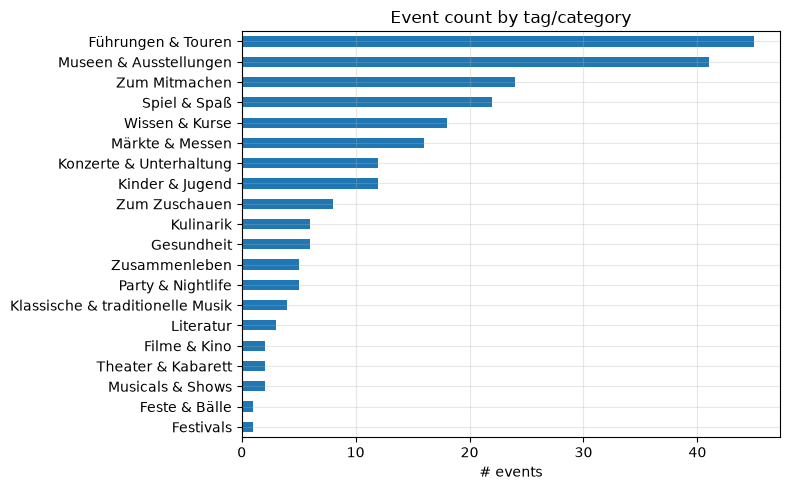

In [17]:
from collections import Counter
tag_counts = Counter()
for tag_ids in events["tag_ids"].dropna():
    for tid in tag_ids:
        tag_counts[tags_lookup.get(tid, tid)] += 1

pd.Series(tag_counts).sort_values(ascending=False).plot(
    kind="barh", title="Event count by tag/category")
plt.xlabel("# events")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

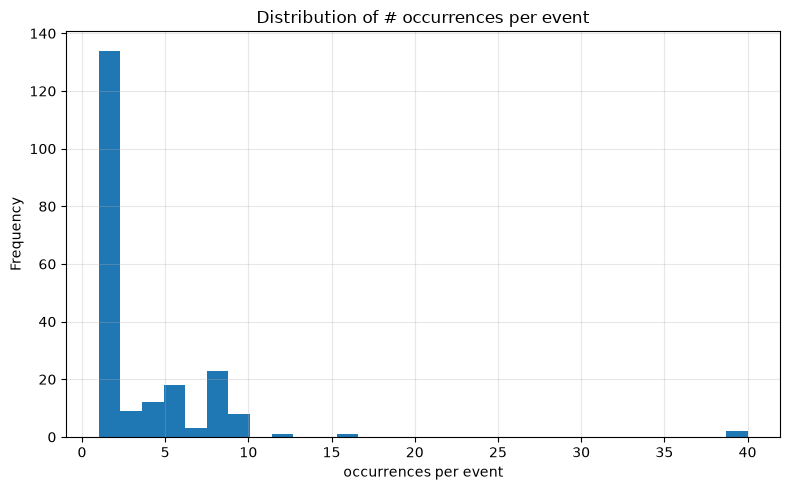

count    211.000000
mean       3.469194
std        4.612896
min        1.000000
25%        1.000000
50%        2.000000
75%        5.000000
max       40.000000
Name: occurrences, dtype: float64


In [18]:
occurrences_per_event = events["occurrences"].dropna().apply(len)
occurrences_per_event.plot(kind="hist", bins=30, title="Distribution of # occurrences per event")
plt.xlabel("occurrences per event")
plt.tight_layout()
plt.show()
print(occurrences_per_event.describe())

## 6. Strassennamen-aktuell — street names & the people behind them

Every street in Linz, and for streets named after a person: their gender,
profession, and birth/death dates. A natural lens for a **"gender gap in public
space naming"** story.

In [19]:
strassen = pd.read_csv("Strassennamen-aktuell.csv")
overview(strassen, "Strassennamen-aktuell")
strassen.head()

=== Strassennamen-aktuell ===
shape: (1211, 17)

id                               str
quell_id                       int64
name                             str
katastralgemeinde                str
beschreibung                     str
detail_url                       str
strasse_wikidata_id              str
strasse_wikidata_url             str
benannt_nach                     str
person_wikidata_id               str
weitere_person_wikidata_ids      str
person_wikidata_url              str
person_name                      str
person_geschlecht                str
person_beruf                     str
person_geburtsdatum              str
person_sterbedatum               str
dtype: object

columns with missing values (share):
weitere_person_wikidata_ids    0.999
strasse_wikidata_id            0.933
strasse_wikidata_url           0.933
person_beruf                   0.633
person_sterbedatum             0.628
person_geburtsdatum            0.628
person_geschlecht              0.627
person_wiki

,id,quell_id,name,katastralgemeinde,beschreibung,detail_url,strasse_wikidata_id,strasse_wikidata_url,benannt_nach,person_wikidata_id,weitere_person_wikidata_ids,person_wikidata_url,person_name,person_geschlecht,person_beruf,person_geburtsdatum,person_sterbedatum
0,strasse_918,918,Achleitnerstraße,Ebelsberg,Vom Hauderweg parallel zur Kremsmünsterer Stra...,https://www.linz.at/strassennamen/Default.asp?...,NaN,NaN,Viktor Achleitner,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,strasse_919,919,Ackerlweg,Pöstlingberg,Gegenüber dem Objekt Gründbergstraße 65 etwa i...,https://www.linz.at/strassennamen/Default.asp?...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,strasse_920,920,Adalbert-Stifter-Platz,Linz,Umfaßt den ehemaligen sogenannten Zollamtplatz...,https://www.linz.at/strassennamen/Default.asp?...,Q107102786,https://www.wikidata.org/wiki/Q107102786,Adalbert Stifter,Q168542,NaN,https://www.wikidata.org/wiki/Q168542,Adalbert Stifter,male,writer,1805-10-23,1868-01-28
3,strasse_921,921,Adelheid-Popp-Weg,Kleinmünchen,Von der Hallestraße etwa in südwestlicher Rich...,https://www.linz.at/strassennamen/Default.asp?...,NaN,NaN,Adelheid Popp,Q34391,NaN,https://www.wikidata.org/wiki/Q34391,Adelheid Popp,female,journalist,1869-02-11,1939-03-07
4,strasse_922,922,Adlergasse,Linz,Vom Hauptplatz heute unterbrochen durch den Ba...,https://www.linz.at/strassennamen/Default.asp?...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


453 / 1211 streets are named after a person

person_geschlecht
male      399
female     53
NaN         1
Name: count, dtype: int64


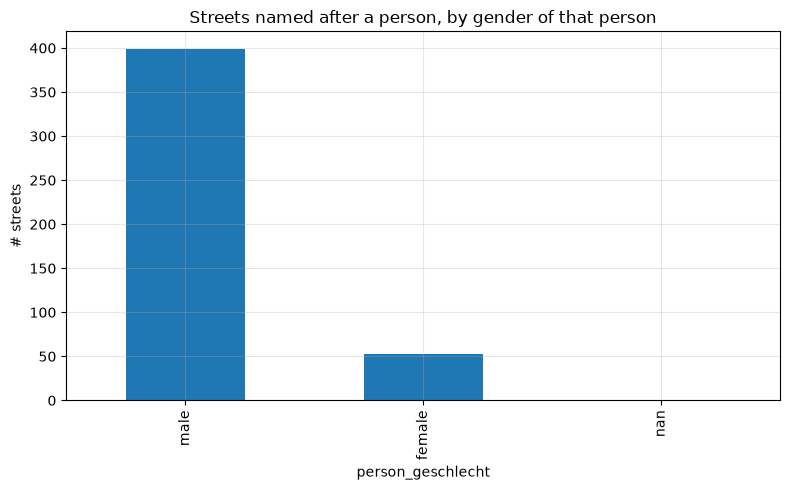

In [20]:
named_after_person = strassen.dropna(subset=["person_name"])
print(f"{len(named_after_person)} / {len(strassen)} streets are named after a person")
print()
gender_counts = named_after_person["person_geschlecht"].value_counts(dropna=False)
print(gender_counts)
gender_counts.plot(kind="bar", title="Streets named after a person, by gender of that person")
plt.ylabel("# streets")
plt.tight_layout()
plt.show()

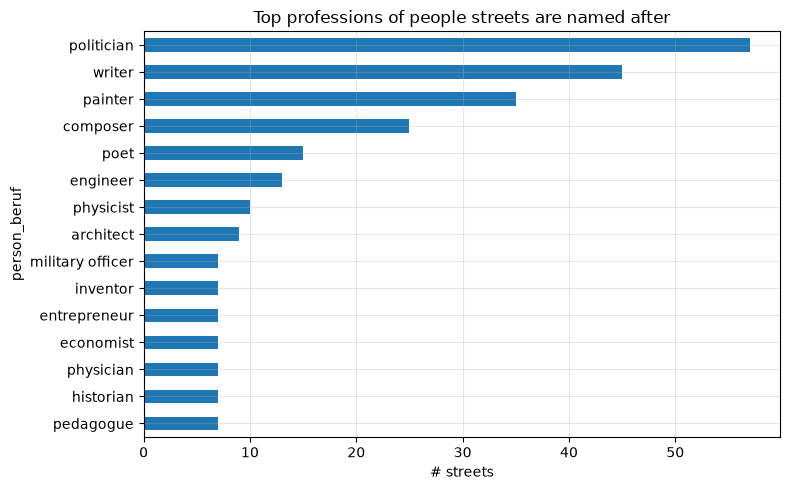

In [21]:
named_after_person["person_beruf"].value_counts().head(15).plot(
    kind="barh", title="Top professions of people streets are named after")
plt.xlabel("# streets")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

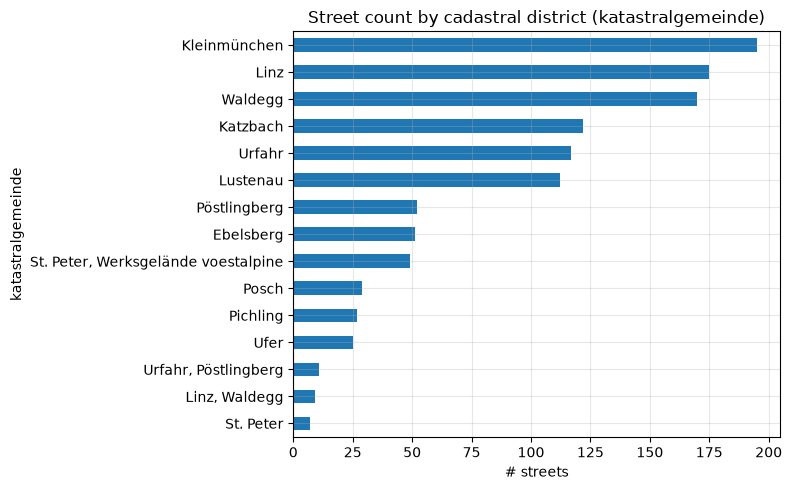

In [22]:
strassen["katastralgemeinde"].value_counts().head(15).plot(
    kind="barh", title="Street count by cadastral district (katastralgemeinde)")
plt.xlabel("# streets")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Trinkbrunnen — public drinking fountains

In [23]:
trinkbrunnen = pd.read_csv("Trinkbrunnen.csv")
overview(trinkbrunnen, "Trinkbrunnen")
trinkbrunnen.head()

=== Trinkbrunnen ===
shape: (132, 29)

id                                         str
nummer_alt                                 str
nummer_neu                                 str
aufstellungsort                            str
brunnenart                                 str
bauart                                     str
epsg31255_x                            float64
epsg31255_y                            float64
lon                                    float64
lat                                    float64
in_betrieb                              object
trinkwasser                               bool
wasseranalyse                             bool
steuerung                                  str
elektrik                                   str
pumpe                                      str
beleuchtung                                str
wassermenge_sammelbecken                   str
lage_brunnentechnik                        str
lage_wasserzaehler                         str
wasserzaehler_epsg312

,id,nummer_alt,nummer_neu,aufstellungsort,brunnenart,bauart,epsg31255_x,epsg31255_y,lon,lat,in_betrieb,trinkwasser,wasseranalyse,steuerung,elektrik,pumpe,beleuchtung,wassermenge_sammelbecken,lage_brunnentechnik,lage_wasserzaehler,wasserzaehler_epsg31255_x,wasserzaehler_epsg31255_y,wasserzaehler_lon,wasserzaehler_lat,lage_e_schaltschrank,lage_stromzaehler,bemerkung,betriebszeit,frostschutz_wasserzaehler_ausgebaut
0,brunnen_bmp01,B01,BmP01,Alter Markt,Zierbrunnen Kein Trinkwasser,Künstlerbrunnen,NaN,NaN,NaN,NaN,NaN,False,False,keine,ja,Grundfos Trockenauf- aufstellung 1 Stück mti Z...,keine,Sammelbecken im Brunnen- schacht ca. 1000 Liter,Schacht bei Brunnen,Schacht bei Brunnen,NaN,NaN,NaN,NaN,Schacht bei Brunnen,Im E-Kasten neben Markthalle,Wasseraufbereitung erfolgt händisch Frischwass...,9:00 bis 21:00,NaN
1,brunnen_bmp02,B02,BmP02,Tummelplatz,Zierbrunnen Kein Trinkwasser,Wasserbecken,NaN,NaN,NaN,NaN,NaN,False,False,keine,ja,"Oase Trockenaufstellung 1 Stück 67 Lit/min 3,4...",keine,Brunnenbecken ca. 500 Liter,Schacht bei Brunnen,Schacht bei Brunnen,NaN,NaN,NaN,NaN,Schacht bei Brunnen,Stromversorgung von Haus Tummelplatz 19,Wasseraufbereitung erfolgt händisch Frischwass...,9:00 bis 21:00,NaN
2,brunnen_bmp03,B03,BmP03,Zollamtstraße,Zierbrunnen Kein Trinkwasser,Steinquader,NaN,NaN,NaN,NaN,NaN,False,False,keine,ja,Unterwasserpumpe mit Zeitsteuerung,keine,Sammelbecken im Brunnen- schacht ca. 1000 Liter,Schacht neben Brunnen,Schacht neben Brunnen,NaN,NaN,NaN,NaN,Schacht neben Brunnen,Privathaus Zollamtstr. 16 (Dolce Vita),Wasseraufbereitung erfolgt händisch Frischwass...,9:00 bis 21:00,NaN
3,brunnen_bmp04,B04,BmP04,Arbeiterkammer,Zierbrunnen Kein Trinkwasser,Steinskultur mit Brunnenbecken,NaN,NaN,NaN,NaN,NaN,False,False,keine,ja,Grundfos Trockenaufstellung 1 Stück mit Zeitst...,keine,Brunnenbecken ca. 30000 Liter,Schacht neben Brunnen,Schacht neben Brunnen,NaN,NaN,NaN,NaN,Schacht neben Brunnen,Keller Arbeiterkammer,Wasseraufbereitung erfolgt händisch Frischwass...,9:00 bis 21:00,NaN
4,brunnen_bmp05,B05,BmP05,Donaupark vor Brucknerhaus (Beyerbrunnen),Zierbrunnen Kein Trinkwasser,18 Metallsäulen in Brunnenbecken mit Quellausl...,NaN,NaN,NaN,NaN,NaN,False,False,keine,ja,Vogel Trocken- aufstellung 1 Stück mit Zeitste...,7 Scheinwerfer im Brunnenschacht mit Glasschei...,Brunnenbecken ca 10000 Liter,Schacht neben Brunnen,2. UG Brucknerhaus,NaN,NaN,NaN,NaN,Schacht neben Brunnen,1. UG Brucknerhaus,Wasseraufbereitung erfolgt händisch Frischwass...,9:00 bis 22:00,NaN


In [24]:
print("in_betrieb (operational):")
print(trinkbrunnen["in_betrieb"].value_counts(dropna=False))
print()
print("trinkwasser (potable):")
print(trinkbrunnen["trinkwasser"].value_counts(dropna=False))
print()
print("brunnenart (fountain type), top values:")
print(trinkbrunnen["brunnenart"].value_counts().head(10))

in_betrieb (operational):
in_betrieb
True     89
NaN      31
False    12
Name: count, dtype: int64

trinkwasser (potable):
trinkwasser
True     98
False    34
Name: count, dtype: int64

brunnenart (fountain type), top values:
brunnenart
Trinkbrunnen                               80
Zierbrunnen Kein Trinkwasser               33
Zierbrunnen Trinkwasserentnahme möglich     8
Bachlauf                                    2
Trinkwasser                                 2
Zierbrunnen                                 1
Trinkbrunnen mit Wattrinne                  1
Wattrinne                                   1
Wattrinnen                                  1
Trinkbrunnen 2011 abgebaut                  1
Name: count, dtype: int64


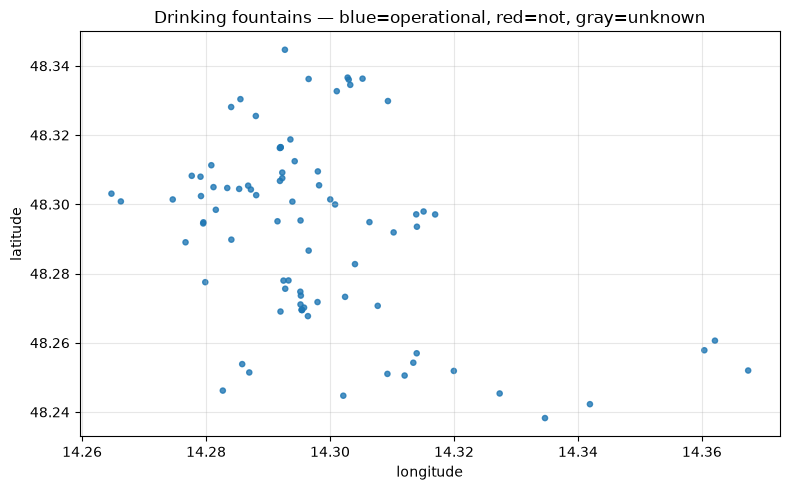

In [25]:
geo = trinkbrunnen.dropna(subset=["lon", "lat"])
fig, ax = plt.subplots()
colors = geo["in_betrieb"].map({True: "tab:blue", False: "tab:red"}).fillna("tab:gray")
ax.scatter(geo["lon"], geo["lat"], s=14, c=colors, alpha=0.8)
ax.set_title("Drinking fountains — blue=operational, red=not, gray=unknown")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
plt.tight_layout()
plt.show()

## 8. WC-Anlagen — public toilets

In [26]:
wc = pd.read_csv("WC-Anlagen.csv")
overview(wc, "WC-Anlagen")
wc.head()

=== WC-Anlagen ===
shape: (68, 14)

id                     str
nummer                 str
art                    str
name                   str
epsg31255_x          int64
epsg31255_y          int64
lon                float64
lat                float64
barrierefrei          bool
eurokey               bool
oeffnungszeiten        str
wickeltisch           bool
wintersperre           str
anmerkung              str
dtype: object

columns with missing values (share):
anmerkung       0.897
wintersperre    0.588
dtype: float64


,id,nummer,art,name,epsg31255_x,epsg31255_y,lon,lat,barrierefrei,eurokey,oeffnungszeiten,wickeltisch,wintersperre,anmerkung
0,wc_1,1,mit Personalbesetztung,Hauptplatz ARH,70795,352404,14.286867,48.305932,True,True,Mo - Fr 7:00-20:00 Sa 5:30 - 20:00 So 8:30 - 2...,True,nein,"Benutzungsgebühr € 0,20,--"
1,wc_2,2,mit Personalbesetztung,"Südbahnhofmarkt an Markttagen Di, Fr, Sa beset...",71843,351867,14.300901,48.300985,True,True,Mo - Sa 06:00 - 18:00 So geschlossen,True,nein,"Benutzungsgebühr € 0,20,--"
2,wc_3,3,ohne Personalbesetztung,Auf der Gugl,70297,351071,14.279934,48.294001,False,False,06:00 - 20:00,False,nein,NaN
3,wc_4,4,ohne Personalbesetztung,Auhof,73270,355619,14.320782,48.334559,True,False,durchgehend,False,nein,NaN
4,wc_5,5,ohne Personalbesetztung,Bergschlösslpark Pförtnergebäude,70715,350789,14.285519,48.291419,True,True,durchgehend,False,Nov - März,NaN


In [27]:
print("barrierefrei (wheelchair accessible):")
print(wc["barrierefrei"].value_counts(dropna=False))
print()
print("wickeltisch (baby changing table):")
print(wc["wickeltisch"].value_counts(dropna=False))
print()
print("art (staffed vs unstaffed):")
print(wc["art"].value_counts(dropna=False))

barrierefrei (wheelchair accessible):
barrierefrei
True     37
False    31
Name: count, dtype: int64

wickeltisch (baby changing table):
wickeltisch
False    47
True     21
Name: count, dtype: int64

art (staffed vs unstaffed):
art
Mobile WC Kabinen                      27
ohne Personalbesetztung                24
in Volkshäuser                         13
mit Personalbesetztung                  3
Externe Betreung (Severin Stiftung)     1
Name: count, dtype: int64


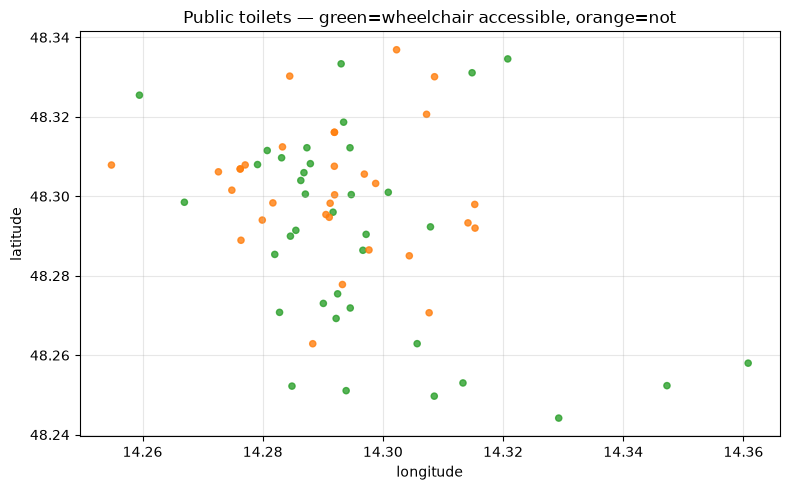

In [28]:
fig, ax = plt.subplots()
colors = wc["barrierefrei"].map({True: "tab:green", False: "tab:orange"}).fillna("tab:gray")
ax.scatter(wc["lon"], wc["lat"], s=20, c=colors, alpha=0.8)
ax.set_title("Public toilets — green=wheelchair accessible, orange=not")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
plt.tight_layout()
plt.show()

## 9. spielplaetze_und_sportanlagen — playgrounds & sports facilities

Semicolon-delimited, Latin-1 encoded. Coordinates come either as a WKT `POINT`
string or as space-grouped `Koordinate Nord`/`Koordinate Ost` fields
(e.g. `48 303 139` -> `48.303139`); we normalize both into `lat`/`lon`.

In [29]:
spiel = pd.read_csv("spielplaetze_und_sportanlagen.csv", sep=";", encoding="latin1")
overview(spiel, "spielplaetze_und_sportanlagen")
spiel.head()

=== spielplaetze_und_sportanlagen ===
shape: (158, 15)

Anlage                  str
Name                    str
Bereich                 str
Bezirksnummer         int64
Bezirksname             str
Stadtteil               str
Art                     str
URL                     str
Koordinaten             str
Straße                  str
Postleitzahl        float64
Ort                     str
Koordinate Nord         str
Koordinate Ost          str
Google-Maps Link        str
dtype: object

columns with missing values (share):
Straße          0.842
Postleitzahl    0.842
Ort             0.842
URL             0.310
Koordinaten     0.120
dtype: float64


,Anlage,Name,Bereich,Bezirksnummer,Bezirksname,Stadtteil,Art,URL,Koordinaten,Straße,Postleitzahl,Ort,Koordinate Nord,Koordinate Ost,Google-Maps Link
0,Sportanlage,Fitnessparcours Freinberg,Freinberg,9,Froschberg,"Freinberg, Bauernberg und Froschberg",Fitnessanlage,NaN,NaN,NaN,NaN,NaN,48 303 139,14 262 694,"https://www.google.at/maps/place/48.303139,14...."
1,Sportanlage,Beach-Volleyball-Anlage Am Damm,Jugendspielwiese am Damm,2,Urfahr,Urfahr,Beach Volleyball,NaN,POINT (14.294362 48.318145),NaN,NaN,NaN,48 318 145,14 294 362,"https://www.google.at/maps/place/48.318145,14...."
2,Sportanlage,Beach-Volleyball-Anlage Bindermichlpark,Landschaftspark Bindermichl,11,Spallerhof,Bindermichl/Spallerhof,Beach Volleyball,NaN,POINT (14.295618 48.271523),NaN,NaN,NaN,48 271 393,14 295 226,"https://www.google.at/maps/place/48.271393,14...."
3,Sportanlage,Beach-Volleyball-Anlage Franckviertel,Ing.-Stern-Straße,7,Franckviertel,Franckviertel,Beach Volleyball,NaN,POINT (14.3165 48.294117),Ing.-Stern-Straße 45 - 47,4020.0,Linz,48 294 563,14 316 456,"https://www.google.at/maps/place/48.294563,14...."
4,Sportanlage,Beach-Volleyball-Anlage Hummelhofbad,Hummelhofbad,10,Bindermichl-Keferfeld,Bindermichl/Spallerhof,Beach Volleyball,NaN,POINT (14.290295 48.275785),Maderspergerstraße 2,4020.0,Linz,48 277 965,14 291 616,"https://www.google.at/maps/place/48.277965,14...."


In [30]:
def parse_coord(value):
    if pd.isna(value):
        return np.nan
    digits = str(value).replace(" ", "").strip()
    if not digits:
        return np.nan
    return float(digits) / 1_000_000

spiel["lat"] = spiel["Koordinate Nord"].apply(parse_coord)
spiel["lon"] = spiel["Koordinate Ost"].apply(parse_coord)
spiel[["Koordinate Nord", "Koordinate Ost", "lat", "lon"]].head()

,Koordinate Nord,Koordinate Ost,lat,lon
0,48 303 139,14 262 694,48.303139,14.262694
1,48 318 145,14 294 362,48.318145,14.294362
2,48 271 393,14 295 226,48.271393,14.295226
3,48 294 563,14 316 456,48.294563,14.316456
4,48 277 965,14 291 616,48.277965,14.291616


Anlage (facility class):
Anlage
Spielanlage    109
Sportanlage     49
Name: count, dtype: int64



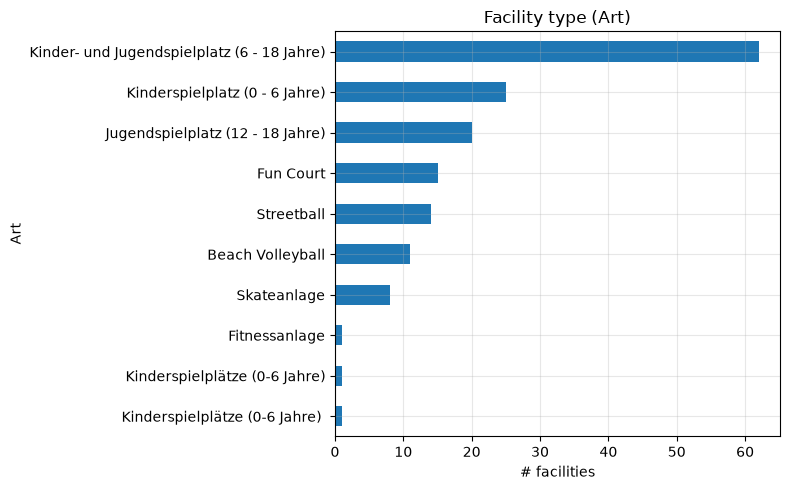

In [31]:
print("Anlage (facility class):")
print(spiel["Anlage"].value_counts())
print()
spiel["Art"].value_counts().plot(kind="barh", title="Facility type (Art)")
plt.xlabel("# facilities")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

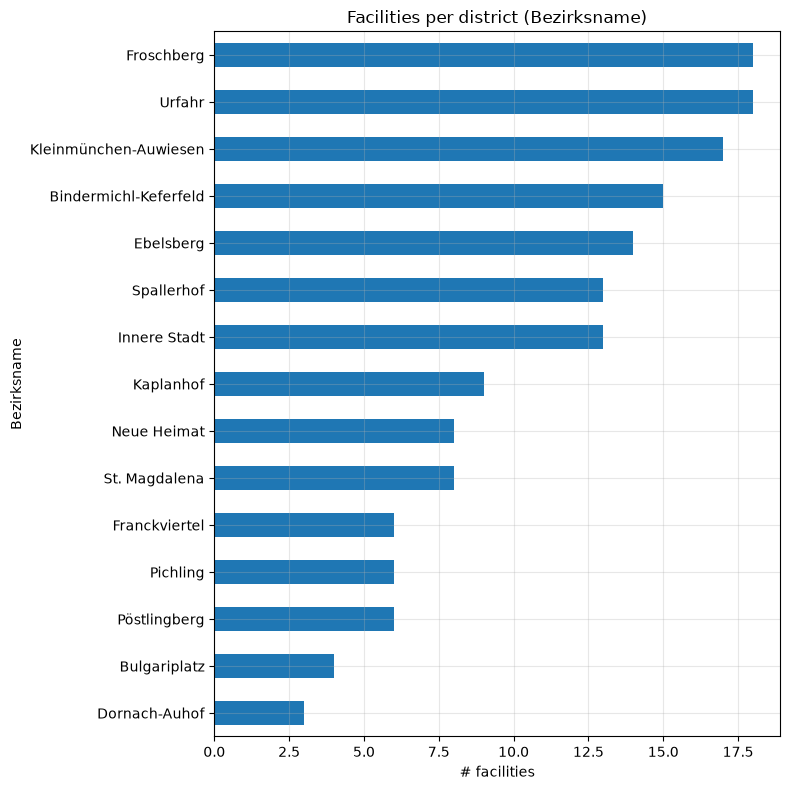

In [32]:
spiel["Bezirksname"].value_counts().plot(
    kind="barh", figsize=(8, 8), title="Facilities per district (Bezirksname)")
plt.xlabel("# facilities")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 10. Cross-dataset view — all point amenities on one map

A quick overlay of every geolocated dataset gives a feel for spatial coverage
and overlap — useful for any "amenity access" / "15-minute city" style topic.

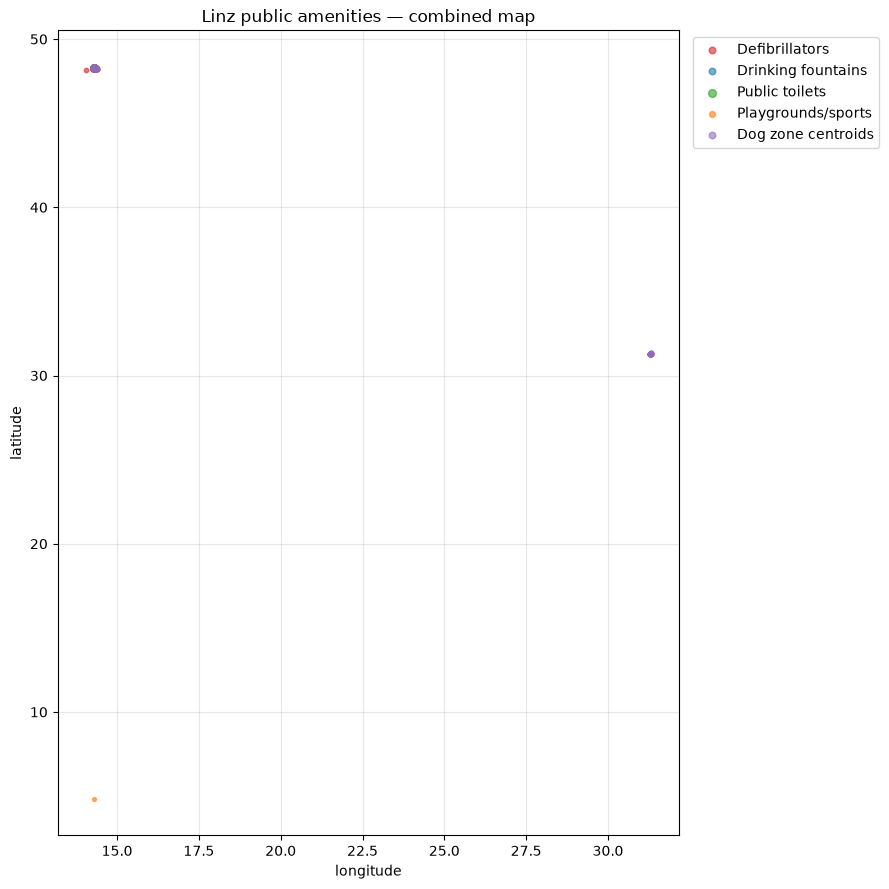

In [33]:
fig, ax = plt.subplots(figsize=(9, 9))

layers = {
    "Defibrillators": (defi["lon"], defi["lat"], "tab:red", 10),
    "Drinking fountains": (trinkbrunnen["lon"], trinkbrunnen["lat"], "tab:blue", 10),
    "Public toilets": (wc["lon"], wc["lat"], "tab:green", 14),
    "Playgrounds/sports": (spiel["lon"], spiel["lat"], "tab:orange", 8),
    "Dog zone centroids": (hundezonen["centroid_lon"], hundezonen["centroid_lat"], "tab:purple", 10),
}

for label, (x, y, color, size) in layers.items():
    ax.scatter(x, y, s=size, c=color, alpha=0.6, label=label)

ax.set_title("Linz public amenities — combined map")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.legend(markerscale=1.5, loc="upper left", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

## 11. Summary & candidate hackathon topics

**What the data actually supports:**

- **Point-amenity datasets with coordinates** (defibrillators, drinking fountains,
  toilets, playgrounds/sports, dog zones) all cover the city of Linz and share a
  lat/lon grain — they combine cleanly into a single "public amenities" layer.
- **Accessibility signal already exists**: `barrierefrei` on toilets, `in_betrieb`/
  `trinkwasser` on fountains — enough to score areas of the city on amenity
  coverage/accessibility, or to spot underserved districts (compare against
  `Bezirksname`/`katastralgemeinde` counts from streets & sports facilities).
- **Strassennamen** gives a clean, ready-made **gender-gap story**: of the streets
  named after a person, men outnumber women roughly 8:1, with profession and
  era (birth/death dates) available to dig further (e.g. is the gap closing for
  more recently named streets?).
- **Linztermine** is a live events feed (211 events, 732 occurrences, 26 tags) —
  supports a recommender/what's-on angle, or a free-vs-paid / kid-friendly
  accessibility angle for city events.
- **Herkunftslaender** is quarterly tourism data by country — good for a
  tourism-trends or seasonality angle, though it's currently only one year (2024)
  so long-term trend analysis isn't possible with this extract alone.
- **Hecken-die-schmecken** is charming but only 21 rows — best used as a small
  enrichment layer (e.g. combined into an "urban foraging / green amenities" map)
  rather than a standalone topic.

**Candidate topics, roughly ranked by how well-supported they are by this data:**

1. **Amenity accessibility / "15-minute city" score per district** — combine
   toilets, fountains, defibrillators, playgrounds, dog zones + district
   boundaries from streets/sports data to find underserved neighborhoods.
2. **Gender gap in Linz street names** — clear, quantifiable, visual (map +
   time trend from birth/death years), minimal extra data needed.
3. **Interactive "what's on in Linz" explorer** — filter Linztermine by tag,
   free/paid, kid-friendly, and location, layered on the amenities map.
4. **Emergency-preparedness map** — defibrillator coverage vs. population
   density / distance-to-nearest-AED, an easy-to-explain public-safety story.
5. **Tourism dashboard** — origin-country breakdown and quarterly seasonality
   from Herkunftslaender (weaker without multi-year history).

Next step: pick one direction and, if needed, go back to the relevant source(s)
above for a deeper, focused EDA.
